## Introducción

Objetivo: **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello se trabajarán con datos reales de TomTom Traffic Index y OECD Cities, que se limpiarán, combinarán y analizarán para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Validar que los archivos se carguen correctamente, conocer sus columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usar `print()` para que la tabla luzca mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos
Inspeccionar su estructura, tipos de datos, columnas y valores faltantes.
Anotar las columnas que necesiten limpieza y luego estandarizar los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:
# Examinar la estructura de traffic
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del DF traffic, se observa que:
- Hay 12 columnas, las cuales 8 son "float64":JamsDelay, TrafficIndexLive, JamsLengthInKms, JamsCount, TrafficIndexWeekAgo, TravelTimeLivePer10KmsMins, TravelTimeHistoricPer10KmsMins y MinsDelay. 4 son "object": Country, City, UpdateTimeUTC y UpdateTimeUTCWeekAgo.
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo "object", sin embargo necesitan conversión a "datatime64", ya que contienen fechas y horas.
- No hay datos faltanes.

In [ ]:
# Examinar la estructura de eco
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del DF "eco", se observa que:
- Tiene 7 columnas, de las cuales 1 es "int64": Year; y el resto son "object": City, Country, City GDP/capita, Unemployment %, PM2.5 (μg/m³) y Population (M).
- Las columnas: City GDP/capita, Unemployment %, PM2.5 (μg/m³) y Population (M) necesitan conversión a tipo "float64", ya que son mediciones numéricas con cantidades decimales.
- No hay datos faltantes.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic_lower= traffic.rename(columns={'Country': 'country', 'City': 'city', 'UpdateTimeUTC': 'update_time_utc',
'JamsDelay': 'jams_delay', 'TrafficIndexLive': 'traffic_index_live', 'JamsLengthInKms': 'jams_length_in_kms',
'JamsCount': 'jams_count', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10_kms_mins', 'TravelTimeHistoricPer10KmsMins':'travel_time_historic_per_10_kms_mins',
'MinsDelay': 'mins_delay'})

# verificar cambios
traffic_lower.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10_kms_mins',
       'travel_time_historic_per_10_kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco_lower= eco.rename(columns={'Year': 'year', 'City': 'city', 'Country': 'country',
'City GDP/capita': 'city_gdp_capita', 'Unemployment %': 'unemployment_pct', 'PM2.5 (μg/m³)': 'pm25',
'Population (M)': 'population_m'})

# verificar cambios
eco_lower.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()

traffic_lower['update_time_utc'] = pd.to_datetime(traffic_lower['update_time_utc'],  errors = "coerce", utc=True)

traffic_lower['update_time_utc_week_ago'] = pd.to_datetime(traffic_lower['update_time_utc_week_ago'],  errors = "coerce", utc=True)

# verificar el cambio
traffic_lower.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                                Non-Null Count    Dtype              
---  ------                                --------------    -----              
 0   country                               1004464 non-null  object             
 1   city                                  1004464 non-null  object             
 2   update_time_utc                       1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                            1004464 non-null  float64            
 4   traffic_index_live                    1004464 non-null  float64            
 5   jams_length_in_kms                    1004464 non-null  float64            
 6   jams_count                            1004464 non-null  float64            
 7   traffic_index_week_ago                1004464 non-null  float64            
 8   update_time_utc_week_ago              1004464 non-null  datetime64[ns, U

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco_lower['city_gdp_capita'] = eco_lower['city_gdp_capita'].astype(str).str.replace('.','').str.replace(',','.').astype(float)
# eco['unemployment_pct'] = ...
eco_lower['unemployment_pct'] = eco_lower['unemployment_pct'].astype(str).str.replace('%','').str.replace(',','.').astype(float)
# eco['population_m'] = ...
eco_lower['population_m'] = eco_lower['population_m'].astype(str).str.replace(',','.').astype(float)
eco_lower['pm25'] = eco_lower['pm25'].astype(str).str.replace(',','.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
# eco['population'] = ...
eco_lower['population'] = eco_lower['population_m']*1000000

# verificar el cambio
eco_lower.info()
eco_lower.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
# traffic_lower['year'] = ...
traffic_lower['year'] = traffic_lower['update_time_utc'].dt.year
# Verificar cambio
traffic_lower.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
traffic_2024 = traffic_lower[traffic_lower['year'] == 2024].copy()
# eco_2024 = ...

eco_2024 = eco_lower[eco_lower['year'] == 2024].copy()


# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


In [ ]:
eco_2024.shape

(15, 8)

In [ ]:
traffic_2024['year'].unique()

array([2024])


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, se calcularán los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_avg = traffic_2024.groupby(['city', 'country', 'year']).agg(
    jams_delay = ('jams_delay', 'mean'),
    traffic_index_live = ('traffic_index_live', 'mean'),
    jams_length_in_kms = ('jams_length_in_kms', 'mean'),
    jams_count = ('jams_count', 'mean'),
    mins_delay = ('mins_delay', 'mean'),
    travel_time_live_per_10_kms_mins = ('travel_time_live_per_10_kms_mins', 'mean'),
    travel_time_historic_per_10_kms_mins = ('travel_time_historic_per_10_kms_mins', 'mean'),
).reset_index()

# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_avg.shape

(387, 10)

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es mexico_city y no me lo esperaba, hace poco hice una investigación con referencia a esto, pero no me puse a analizar que ciudad había llegado al Top 1, solo tome algunas ciudades para investigar como era el tráfico, sin embargo me sorprende bastante este resultado porque creo que estaba confundiendo el tráfico con la métrica de ciudades más contaminadas.


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10_kms_mins','travel_time_historic_per_10_kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
# eco_2024_small = ...
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0


In [ ]:
merged.shape

(15, 14)

In [ ]:
merged['country'].nunique()

7


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que se tiene un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

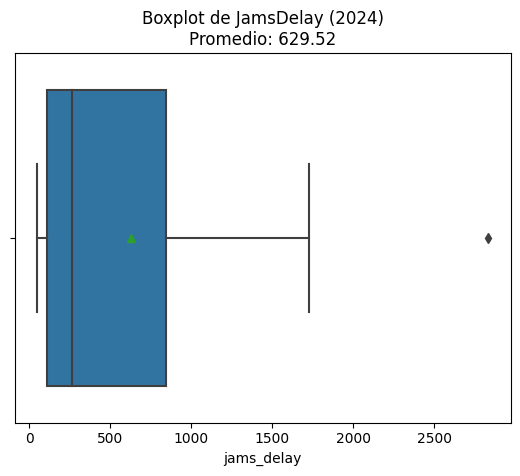

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
sns.boxplot(data=merged, x='jams_delay', showmeans=True)
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


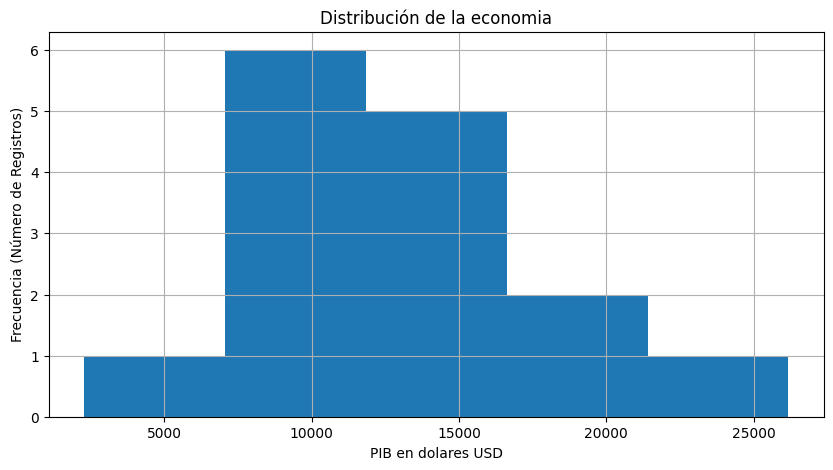

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
eco_2024['city_gdp_capita'].hist(bins=5, figsize=(10, 5)) # figsize=(ancho, alto)
plt.title('Distribución de la economia')
plt.xlabel('PIB en dolares USD')
plt.ylabel('Frecuencia (Número de Registros)')
plt.show()



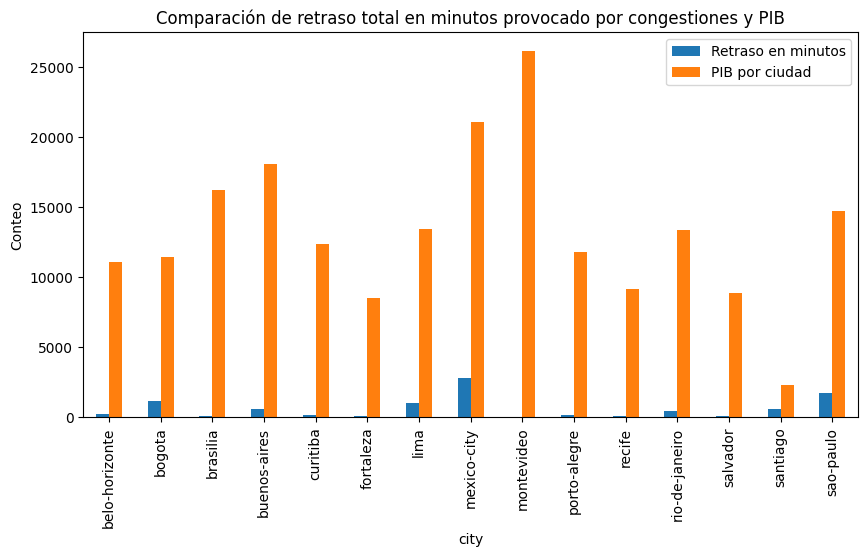

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
merged.plot(x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar', figsize=(10,5))
plt.title('Comparación de retraso total en minutos provocado por congestiones y PIB')
plt.ylabel('Conteo')
plt.xticks(rotation=90)
plt.legend(['Retraso en minutos', 'PIB por ciudad'])
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Considero que no existe una relación clara entre ciudades con mayor PIB, así como con mayor congestión
y viceversa. Debido a que, si prestamos atención la ciudad Montevideo es la que presenta mayor PIB, sin embargo en este gráfico no vemos que presente congestiones, probablemente porque tiene un nivel sumamente bajo. En cambio, si analizamos la ciudad de México, podemos apreciar que es la segunda más alta en niveles de PIB, pero al mismo tiempo es el primer lugar en congestiones. Debemos tener en cuenta que estos resultados pueden verse influenciados por otros factores como el uso del transporte público, la insfraestructura vial o el tamaño de la población, ya que Montevideo tiene apenas 2,4 millones de personas, mientras que la ciudad de México alcanza los 9.2 millones de personas.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final se consolidará todo el trabajo: guardando el dataset limpio y creando un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

- El objetivo del American Development Bank fue identificar en qué ciudades es recomendable invertir en infraestructura de transporte, analizando la relación entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita), usando datos de TomTom Traffic Index y OECD Cities.


**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.
- Este análisis esta enfocado en el año 2024 abarcando 15 ciudades de 7 países distintos, basado en 14 variables, las cuales 2 corresponden a identificadores: ciudad y país, y 12 a métricas: jams_delay, traffic_index_live, jams_length_in_kms, jams_count, mins_delay, travel_time_live_per_10_kms_mins, travel_time_historic_per_10_kms_mins, city_gdp_capita, unemployment_pct, pm25, population, year.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).
  
- Se realizó una limpieza de datos en la estructura del DF traffic, ya que las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo eran de tipo "object" y necesitaban conversión a "datatime64", ya que contienen fechas y horas. Así mismo, en el Dataset eco se hizo limpieza de los valores numéricos en: city_gdp_capita eliminando separadores de miles (.) y reemplazando las comas por puntos para después convertir a tipo float; en unemployment_pct se eliminó el símbolo de porcentaje y reemplazó las comas por puntos antes de convertir a tipo float; en population_m y pm25 se reemplazó las comas por puntos y se convirtió a tipo float; y se creó una nueva columna llamada population multiplicando population_m por 1,000,000 para obtener la población total.
- Fue necesario un proceso de estandarización de columnas de ambos datasets: traffic y eco, renombrando los nombres a formato snake_case, para después extraer el año de la columna fecha y filtrar solo los registros del 2024, creando después los dataframes "traffic_2024" y "eco_2024".
- Se agruparon los datos por city, country y year en el dataset "traffic".
- Se realizó un JOIN INNER para crear una nueva tabla que contenía datos tanto del dataset traffic como del dataset eco con el propósito de mostrar variables de tráfico y economía, usando como claves de unión a "city" y "year".
- Para tener una mejor comprensión de los datos se realizaron 3 gráficos: un Boxplot para visualizar la distribución del tráfico (jams_delay) a través de la mediana, cuartiles (Q1 y Q3) y valores atípicos (outliers); un Histograma para mostrar la distribución de la economía (city_gdp_capita); y el último de Barras para comparar si existía relación entre las congestiones de las ciudades y el Producto Interno Bruto generado por cada una.


**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
- Observando las gráficas anteriores, notamos que la relación entre congestiones y la productividad económica (PIB per cápita), no parecen tener influencia una sobre la otra; ya que, analizando la ciudad Montevideo es la que presenta mayor PIB, sin embargo en el gráfico no se aprecia que presente congestiones, debido a que probablemente tiene un nivel sumamente bajo. Respecto a la ciudad de México, por ejemplo, es la segunda más alta en niveles de PIB, pero al mismo tiempo es el primer lugar en congestiones. Por ello, es necesario tener en cuenta que estos resultados pueden verse influenciados por otros factores como el uso del transporte público, la infraestructura vial o el tamaño de la población, ya que Montevideo tiene apenas 1,800,000.0 de personas, mientras que la ciudad de México alcanza los 22,100,000.0 de personas, por lo que es conveniente analizar métricas como estas para tener datos más acertados.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

- Se recomienda brindar apoyo externo a la ciudad de Santiago, debido a que se posiciona en último lugar con respecto al PIB: 2,277 USD, el cual es muy bajo comparado con el resto de ciudades y presenta una congestión media-alta de 629.86 minutos, que por su rango en PIB supera su capacidad de autofinanciamiento; así como a Bogotá, ya que aunque tiene un PIB  mucho más alto que la ciudad anterior: 11,442 USD, tiene un nivel de congestión muy alto de 1,141.55 minutos, lo cual demuestra un problema de mayor magnitud que supera la capacidad de resolverlo por si sola, además de ser el cuarto lugar en nivel de desempleo con un 10%, número que representa el porcentaje de personas que podrían contribuir al PIB, pero por falta de oportunidades laborales no pueden hacerlo. Contrario a Buenos Aires, que podría autofinanciarse por tener un PIB alto 18,117 USD y un nivel de congestión manejable de 571.08 minutos o Brasilia con un PIB de 16,251 USD y un nivel de congestión bajo/manejable de 101.57 minutos.

In [ ]:
merged.sort_values('city_gdp_capita', ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10_kms_mins,travel_time_historic_per_10_kms_mins,city_gdp_capita,unemployment_pct,pm25,population
8,montevideo,URY,2024,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,26176.0,8.4,11.2,1800000.0
7,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,21111.0,3.2,22.3,22100000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15400000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4800000.0
14,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,14703.0,8.5,28.0,22600000.0
6,lima,PER,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,13472.0,6.5,19.7,11200000.0
11,rio-de-janeiro,BRA,2024,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,13349.0,9.2,18.4,13700000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3700000.0
9,porto-alegre,BRA,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,11801.0,8.7,14.2,4300000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11300000.0
